# Notebook 03 — Thresholding (Lane Pixel Extraction)

After perspective warping, we have a top-down view of the road. Now we need to extract just the lane pixels and discard everything else (asphalt, shadows, debris, lane markings on adjacent lanes, etc.).

We use **two complementary techniques** combined with logical OR:

1. **Sobel x-gradient** — finds vertical edges (lane lines have strong left-right brightness change)
2. **HLS color thresholding** — converts to Hue/Lightness/Saturation color space:
   - High saturation → yellow lane lines
   - High lightness → white lane lines

The combined output is a **binary mask**: pixels are either 0 (not lane) or 255 (lane).

This step is the most parameter-heavy part of the classical pipeline. Different lighting conditions favor different thresholds, which is one reason traditional CV is brittle. We will tune on a few sample images and then test how well our parameters generalize.

## 1. Setup

We import our perspective module and warp a sample to get the bird's-eye view we will threshold.

Loaded: clips/0530/1492626760788443246_0/20.jpg
BEV shape: (720, 720, 3), dtype: uint8


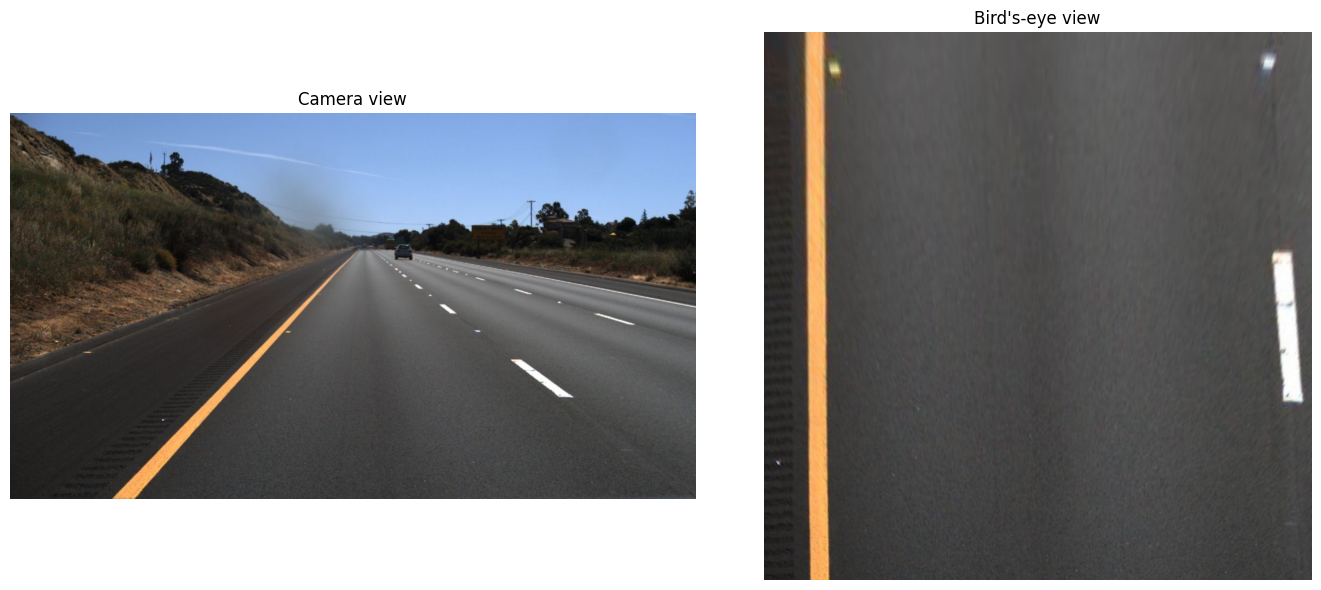

In [7]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import cv2
import numpy as np
import matplotlib.pyplot as plt

from tusimple_loader import TuSimpleDataset
from perspective import PerspectiveWarper

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["figure.dpi"] = 100

dataset = TuSimpleDataset(
    annotation_file=project_root / "data/tusimple/test_subset/test_label_subset.json",
    image_root=project_root / "data/tusimple/test_subset",
)

warper = PerspectiveWarper()

# Pick a sample, load, and warp
sample = dataset[0]
img_bgr = cv2.imread(str(sample.image_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
bev = warper.warp_image(img_rgb)

print(f"Loaded: {sample.raw_file}")
print(f"BEV shape: {bev.shape}, dtype: {bev.dtype}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(img_rgb); axes[0].set_title("Camera view"); axes[0].axis("off")
axes[1].imshow(bev); axes[1].set_title("Bird's-eye view"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## 2. Look at HLS channels

Before we threshold, let's just *see* what the HLS channels look like for our bird's-eye view. This builds intuition for why we threshold S and L specifically.

OpenCV's `cv2.cvtColor` with the flag `COLOR_RGB2HLS` returns a 3-channel image where:
- Channel 0 = H (hue), values 0–179
- Channel 1 = L (lightness), values 0–255
- Channel 2 = S (saturation), values 0–255

The yellow lane should pop in **S** (very saturated), the white dashed lane should pop in **L** (very bright).

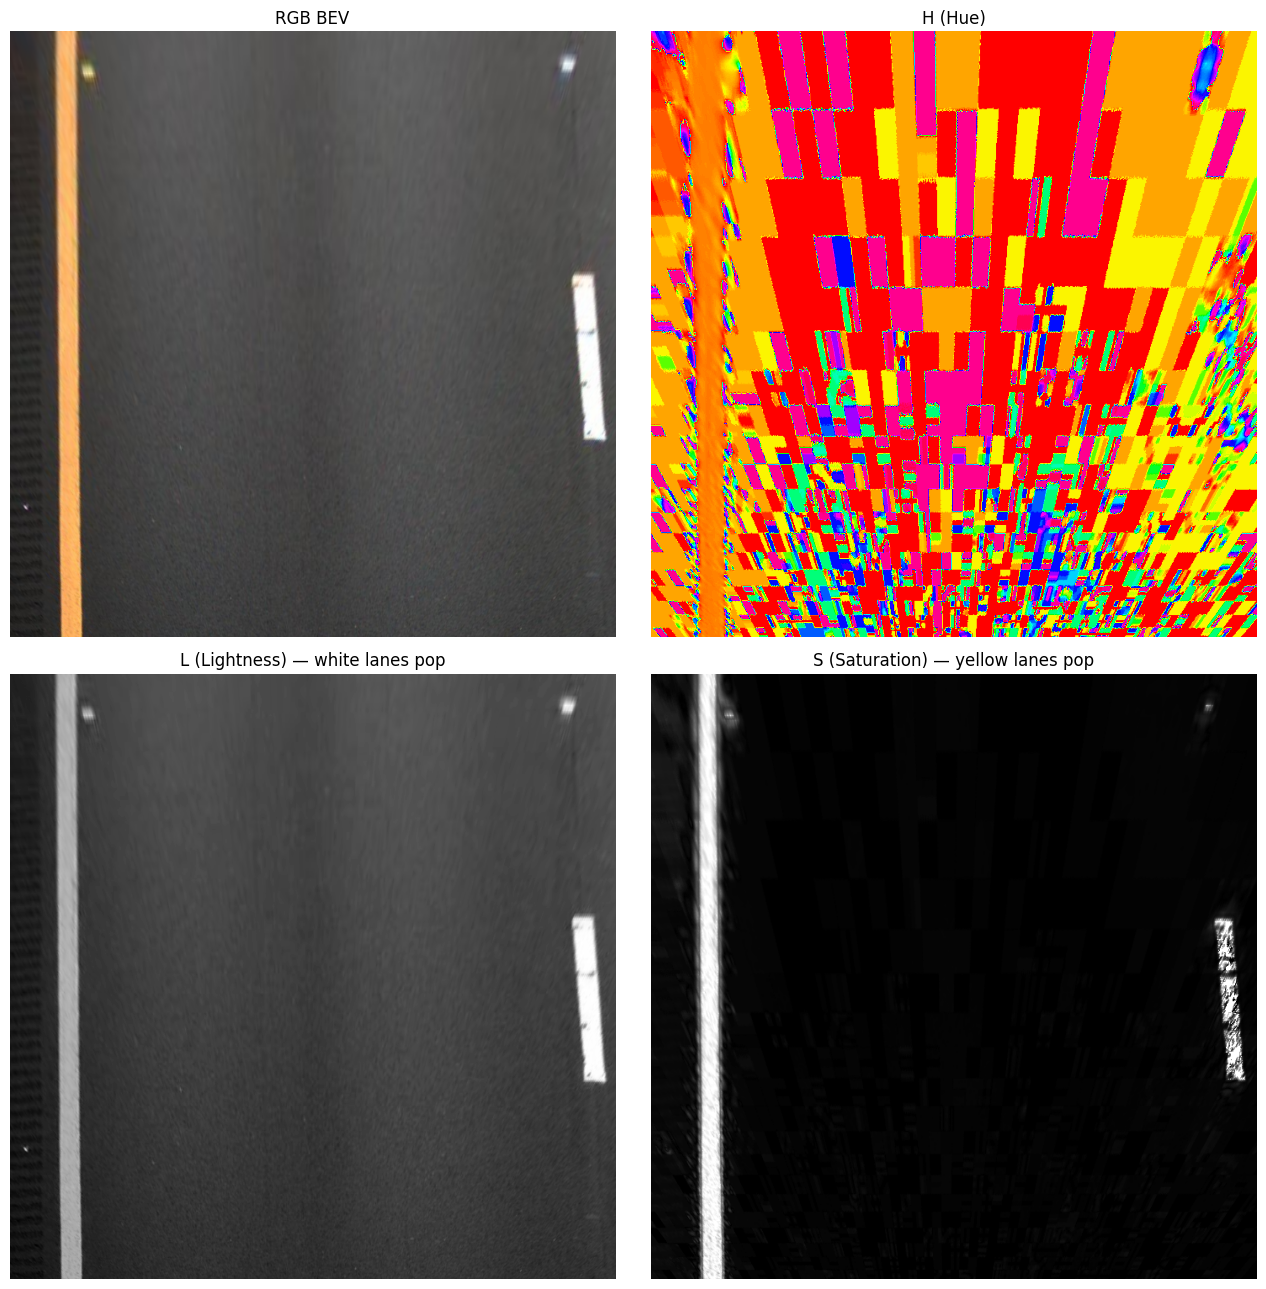

In [8]:
# Convert to HLS
hls = cv2.cvtColor(bev, cv2.COLOR_RGB2HLS)
h_channel = hls[:, :, 0]
l_channel = hls[:, :, 1]
s_channel = hls[:, :, 2]

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
axes[0, 0].imshow(bev);              axes[0, 0].set_title("RGB BEV")
axes[0, 1].imshow(h_channel, cmap="hsv");  axes[0, 1].set_title("H (Hue)")
axes[1, 0].imshow(l_channel, cmap="gray"); axes[1, 0].set_title("L (Lightness) — white lanes pop")
axes[1, 1].imshow(s_channel, cmap="gray"); axes[1, 1].set_title("S (Saturation) — yellow lanes pop")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Sobel x-gradient

`cv2.Sobel(image, cv2.CV_64F, dx=1, dy=0, ksize=3)` computes the x-derivative using a 3x3 Sobel kernel.

- `dx=1, dy=0` → x-direction derivative (catches vertical edges)
- `cv2.CV_64F` → float64 output (so we can have negative values; uint8 would clip them)

After computing the derivative we take the **absolute value** (we don't care if the lane edge is light-on-dark or dark-on-light) and rescale to 0–255 for thresholding.

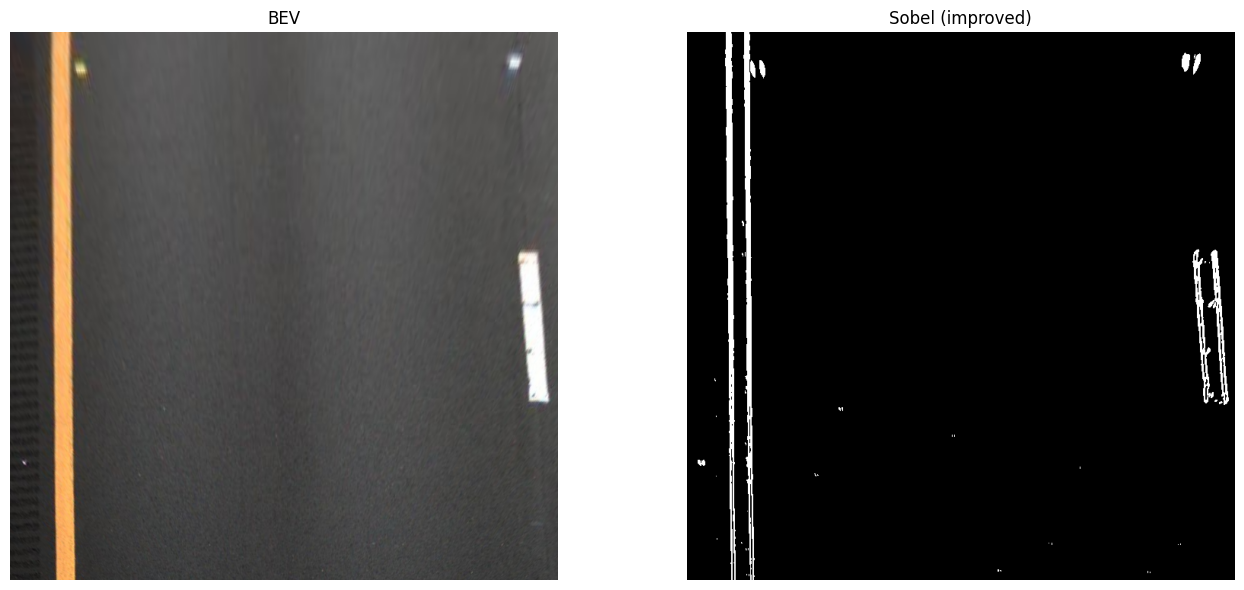

In [9]:
def sobel_x_threshold(image_rgb: np.ndarray, ksize: int = 5,
                      thresh_low: int = 25, thresh_high: int = 200,
                      blur_size: int = 3) -> np.ndarray:
    """Return a binary mask where vertical edges are detected.

    Improvements over baseline:
    - Larger Sobel kernel (5x5 instead of 3x3) — less sensitive to single-pixel noise
    - Pre-blur with small Gaussian — removes asphalt-texture noise before differentiation
    - Higher thresh_low (25) — rejects weak edges from concrete cracks
    """
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    
    # Gaussian blur to smooth texture noise (especially the warped bottom rows)
    if blur_size > 0:
        gray = cv2.GaussianBlur(gray, (blur_size, blur_size), 0)
    
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=ksize)
    abs_sobel = np.abs(sobel_x)
    scaled = np.uint8(255 * abs_sobel / np.max(abs_sobel))
    
    mask = np.zeros_like(scaled)
    mask[(scaled >= thresh_low) & (scaled <= thresh_high)] = 255
    return mask


sobel_mask = sobel_x_threshold(bev)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(bev); axes[0].set_title("BEV")
axes[1].imshow(sobel_mask, cmap="gray"); axes[1].set_title("Sobel (improved)")
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()

## 4. HLS color thresholding

Two complementary thresholds:
- **S-channel high pass** — pixels with saturation above a threshold are likely yellow lane lines
- **L-channel high pass** — pixels with lightness above a threshold are likely white lane lines

We OR them together to catch both yellow and white lanes.

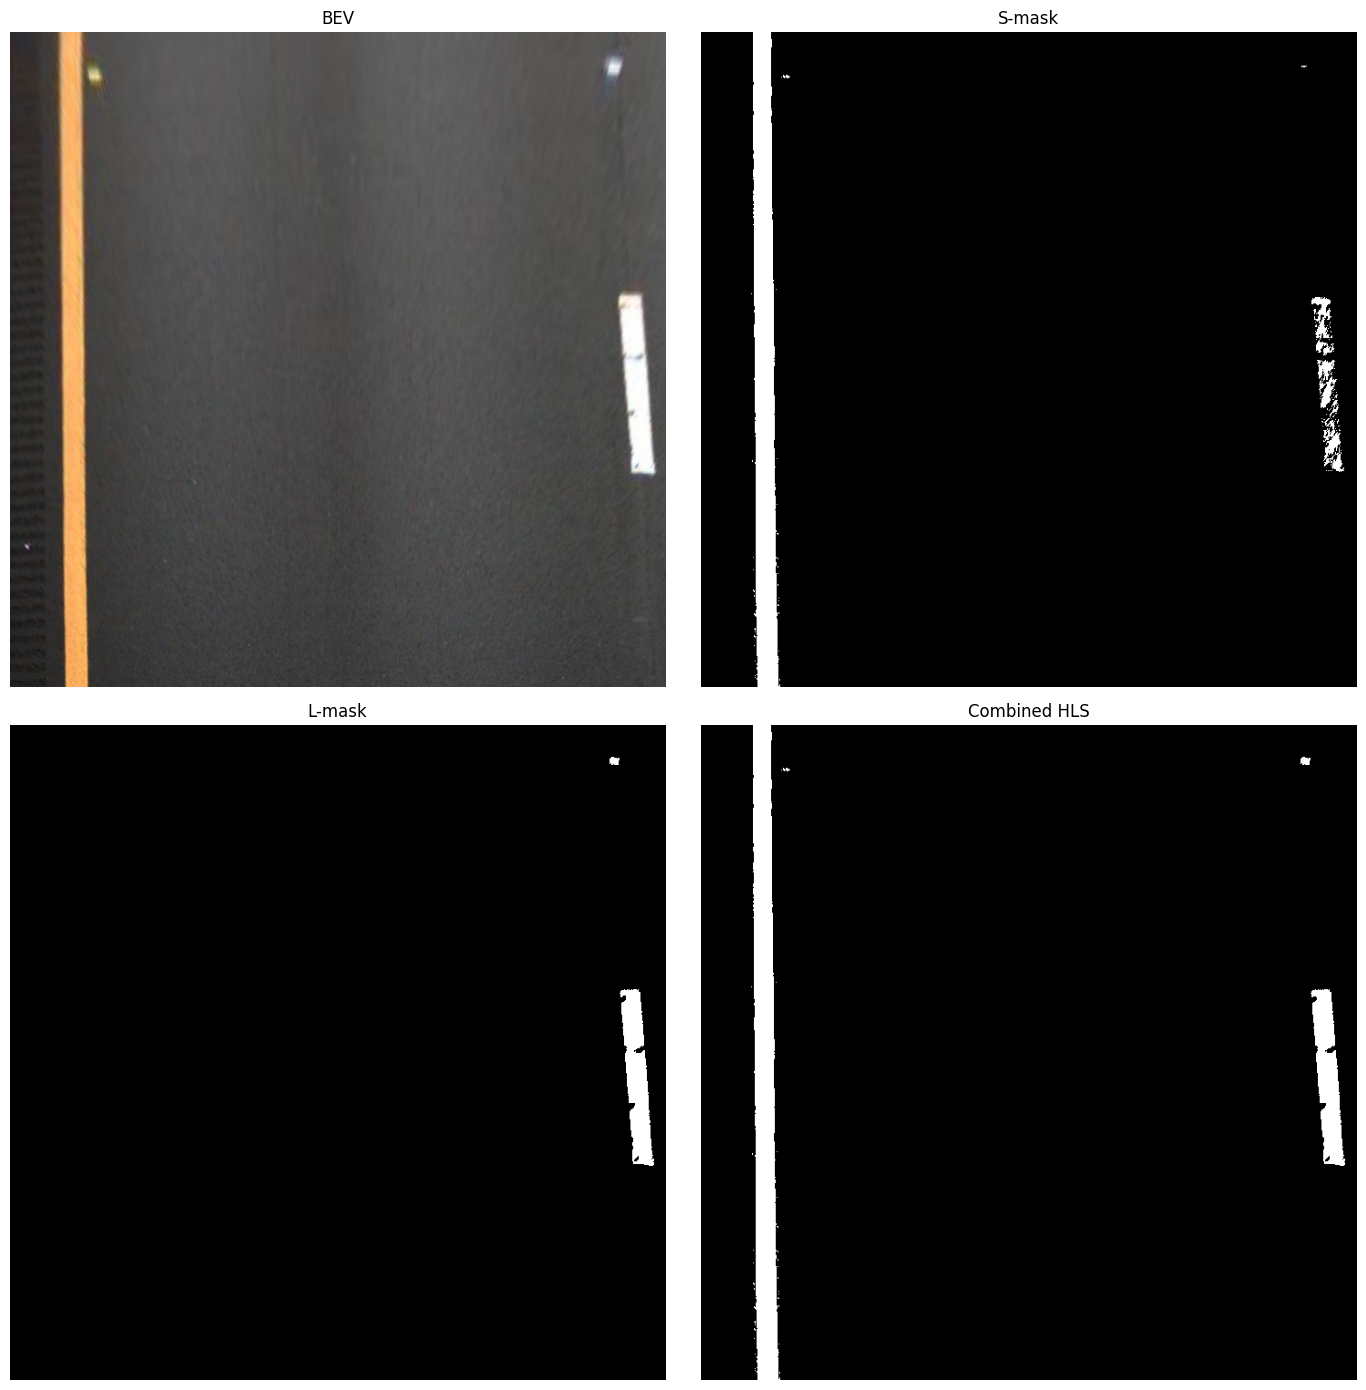

In [10]:
def hls_color_threshold(image_rgb: np.ndarray,
                         s_thresh: tuple = (130, 255),
                         l_thresh: tuple = (220, 255)) -> tuple:
    """HLS-based lane mask. Catches yellow (S) and white (L) lanes.

    Tuning notes:
    - l_thresh raised to 220 (from 200) — lower bound was triggering on light asphalt and concrete
    - s_thresh kept at 130 — yellow lanes have very high saturation, this is a clean threshold
    """
    hls = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HLS)
    l_ch = hls[:, :, 1]
    s_ch = hls[:, :, 2]
    
    s_mask = np.zeros_like(s_ch)
    s_mask[(s_ch >= s_thresh[0]) & (s_ch <= s_thresh[1])] = 255
    
    l_mask = np.zeros_like(l_ch)
    l_mask[(l_ch >= l_thresh[0]) & (l_ch <= l_thresh[1])] = 255
    
    combined = np.zeros_like(s_ch)
    combined[(s_mask == 255) | (l_mask == 255)] = 255
    return combined, s_mask, l_mask


color_mask, s_mask, l_mask = hls_color_threshold(bev)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes[0, 0].imshow(bev); axes[0, 0].set_title("BEV")
axes[0, 1].imshow(s_mask, cmap="gray"); axes[0, 1].set_title("S-mask")
axes[1, 0].imshow(l_mask, cmap="gray"); axes[1, 0].set_title("L-mask")
axes[1, 1].imshow(color_mask, cmap="gray"); axes[1, 1].set_title("Combined HLS")
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Combined thresholding

Final mask = Sobel mask OR HLS color mask. This catches:
- Things that are color-bright (HLS) — solid lane lines
- Things that have strong vertical edges (Sobel) — even faded or partly occluded lanes that retain their edge character

We also overlay the result on the BEV in red so we can see where the detections fall.

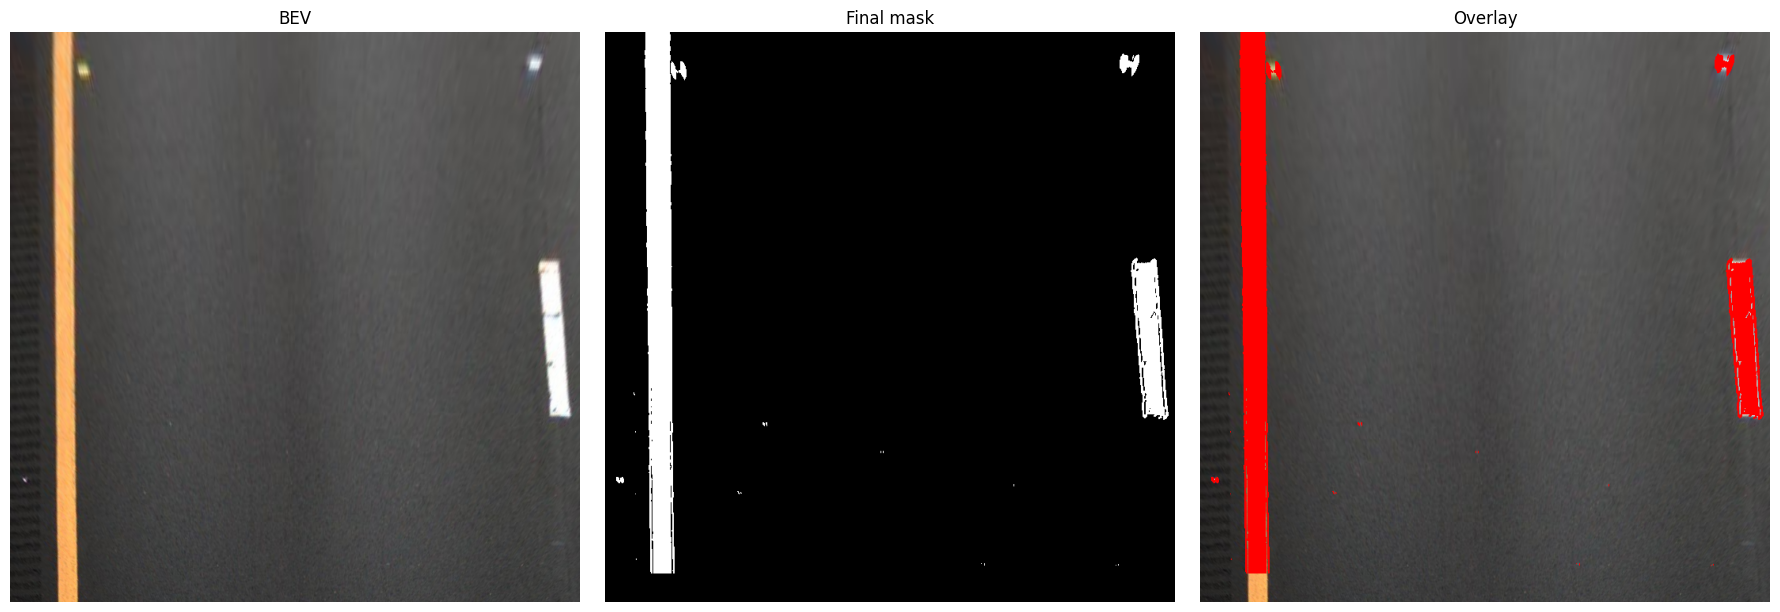

Lane pixels: 27408 (5.29%)


In [11]:
def make_roi_mask(shape: tuple, top_margin: float = 0.0,
                   bottom_margin: float = 0.05) -> np.ndarray:
    """Create a region-of-interest mask. White inside ROI, black outside.

    Args:
        shape: (H, W) of the binary mask.
        top_margin:    fraction to discard from top (0 = keep all)
        bottom_margin: fraction to discard from bottom (0.05 = drop bottom 5%)
    """
    H, W = shape
    roi = np.ones(shape, dtype=np.uint8) * 255
    top_cut = int(H * top_margin)
    bot_cut = int(H * bottom_margin)
    roi[:top_cut, :] = 0
    roi[H - bot_cut:, :] = 0
    return roi


def threshold_pipeline(image_rgb: np.ndarray) -> np.ndarray:
    """Full thresholding pipeline. Returns a binary lane-pixel mask."""
    sobel = sobel_x_threshold(image_rgb)
    color, _, _ = hls_color_threshold(image_rgb)
    
    combined = np.zeros_like(sobel)
    combined[(sobel == 255) | (color == 255)] = 255
    
    # Apply ROI mask — kill noise at extreme edges
    roi = make_roi_mask(combined.shape, top_margin=0.0, bottom_margin=0.05)
    combined[roi == 0] = 0
    
    return combined


final_mask = threshold_pipeline(bev)
overlay = bev.copy()
overlay[final_mask == 255] = [255, 0, 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(bev); axes[0].set_title("BEV")
axes[1].imshow(final_mask, cmap="gray"); axes[1].set_title("Final mask")
axes[2].imshow(overlay); axes[2].set_title("Overlay")
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()

print(f"Lane pixels: {np.sum(final_mask == 255)} ({100 * np.sum(final_mask == 255) / final_mask.size:.2f}%)")

## 6. Test on multiple samples

Tuning on a single image is risky — the thresholds might overfit to that scene. Let's check 6 diverse samples and confirm our pipeline finds lanes in all of them.

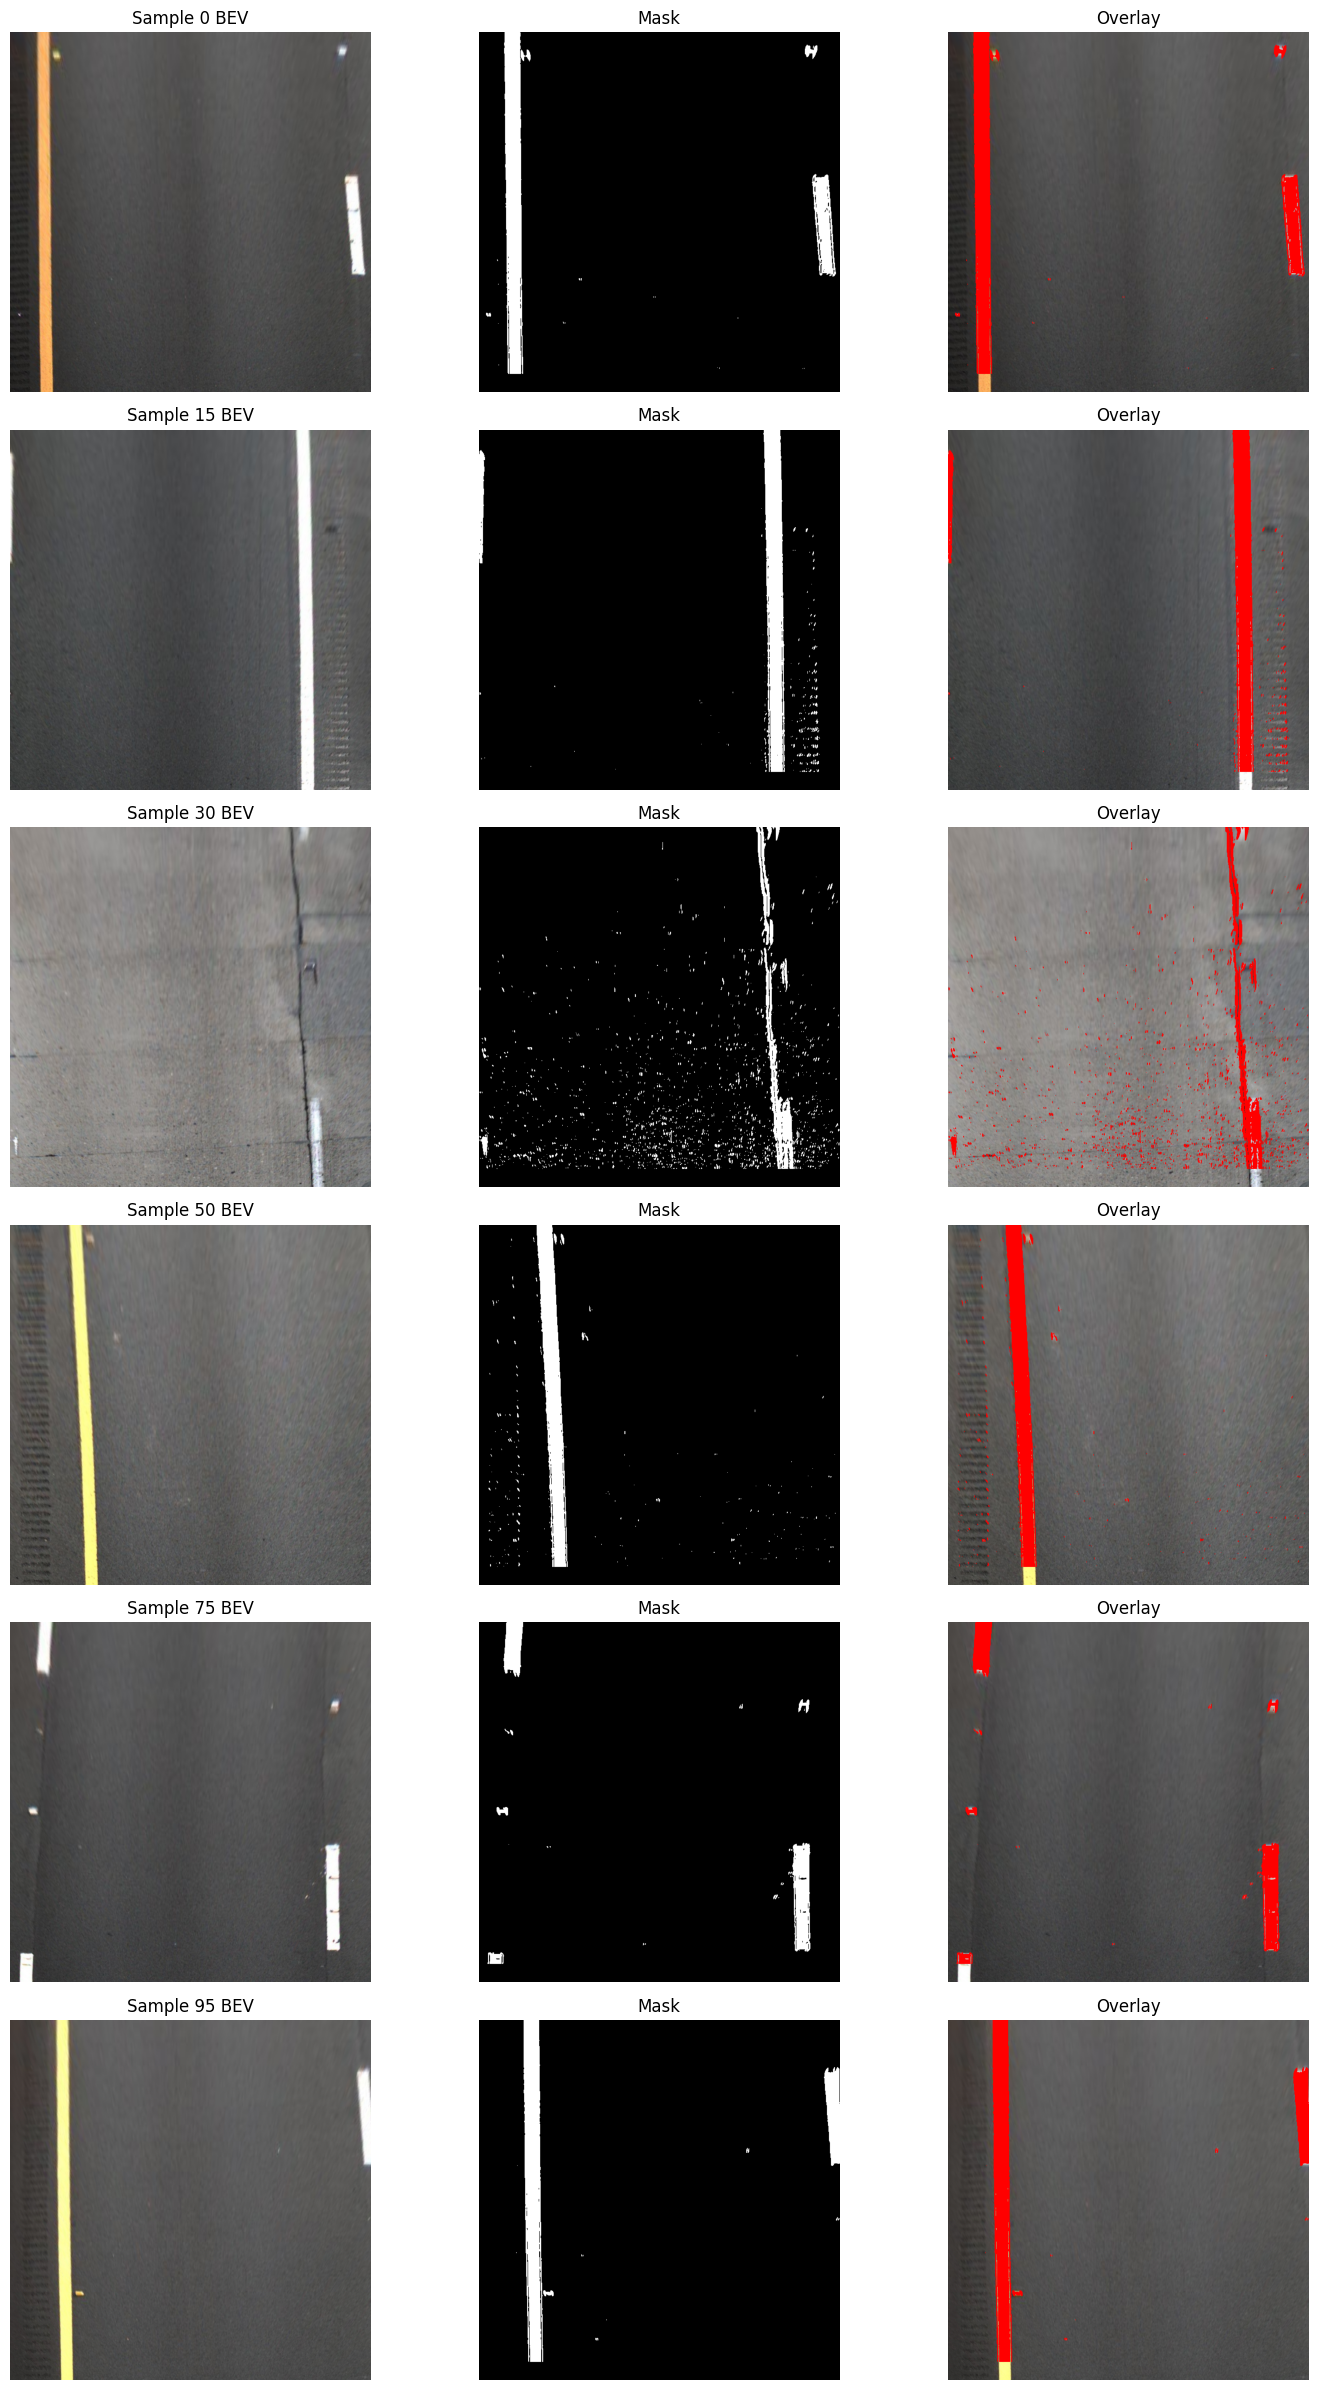

In [12]:
sample_indices = [0, 15, 30, 50, 75, 95]

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(15, 4 * len(sample_indices)))

for row, idx in enumerate(sample_indices):
    s = dataset[idx]
    img = cv2.cvtColor(cv2.imread(str(s.image_path)), cv2.COLOR_BGR2RGB)
    bev_i = warper.warp_image(img)
    mask = threshold_pipeline(bev_i)
    overlay_i = bev_i.copy()
    overlay_i[mask == 255] = [255, 0, 0]
    
    axes[row, 0].imshow(bev_i); axes[row, 0].set_title(f"Sample {idx} BEV")
    axes[row, 1].imshow(mask, cmap="gray"); axes[row, 1].set_title("Mask")
    axes[row, 2].imshow(overlay_i); axes[row, 2].set_title("Overlay")
    
    coverage = 100 * np.sum(mask == 255) / mask.size
    axes[row, 0].set_xlabel(f"{coverage:.1f}% lane pixels")
    
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout(); plt.show()

## 7. Quantitative check against ground truth

Visual inspection is subjective. Let's quantify how well our thresholding captures real lane pixels.

For each sample, we:
1. Warp the ground-truth (x, y) points through M to get their position in the BEV
2. Build a "GT mask" by drawing a thick line through those points
3. Compute **recall** = fraction of GT pixels that our mask also marks as lane
4. Compute **precision** = fraction of our predicted lane pixels that are actually near GT lanes

A good thresholding should have:
- **Recall > 60%** (we find most of the actual lanes)
- **Precision > 20%** (most of our hits are near real lanes — perfect 100% is unrealistic since we use thick lines)

These don't replace the final TuSimple metric (which we'll do later) but give us a quick sanity-check during tuning.

In [13]:
def make_gt_mask(sample, warper, shape, line_thickness: int = 30) -> np.ndarray:
    """Build a GT lane mask in BEV space by warping the GT points and drawing thick lines."""
    gt_mask = np.zeros(shape, dtype=np.uint8)
    for lane_idx in range(sample.num_lanes):
        pts = sample.get_lane_points(lane_idx)
        if len(pts) < 2:
            continue
        warped_pts = warper.warp_points(np.array(pts, dtype=np.float32))
        # Keep points inside the BEV
        mask = (
            (warped_pts[:, 0] >= 0) & (warped_pts[:, 0] < shape[1])
            & (warped_pts[:, 1] >= 0) & (warped_pts[:, 1] < shape[0])
        )
        in_frame = warped_pts[mask].astype(np.int32)
        if len(in_frame) >= 2:
            cv2.polylines(gt_mask, [in_frame], isClosed=False,
                           color=255, thickness=line_thickness)
    return gt_mask


def evaluate_mask(pred_mask: np.ndarray, gt_mask: np.ndarray) -> dict:
    """Compute pixel-level recall and precision."""
    pred_bool = pred_mask == 255
    gt_bool = gt_mask == 255
    
    intersection = pred_bool & gt_bool
    
    recall = intersection.sum() / max(gt_bool.sum(), 1)
    precision = intersection.sum() / max(pred_bool.sum(), 1)
    
    return {
        "recall": recall,
        "precision": precision,
        "gt_pixels": gt_bool.sum(),
        "pred_pixels": pred_bool.sum(),
    }


# Run over multiple samples
sample_indices = list(range(0, 100, 10))  # every 10th sample
print(f"{'idx':>4} | {'recall':>8} | {'precision':>9} | {'pred px':>8} | {'gt px':>8}")
print("-" * 55)

recalls, precisions = [], []
for idx in sample_indices:
    s = dataset[idx]
    img = cv2.cvtColor(cv2.imread(str(s.image_path)), cv2.COLOR_BGR2RGB)
    bev_i = warper.warp_image(img)
    pred = threshold_pipeline(bev_i)
    gt = make_gt_mask(s, warper, bev_i.shape[:2], line_thickness=30)
    metrics = evaluate_mask(pred, gt)
    recalls.append(metrics["recall"])
    precisions.append(metrics["precision"])
    print(f"{idx:>4} | {metrics['recall']:>8.2%} | {metrics['precision']:>9.2%} "
          f"| {metrics['pred_pixels']:>8d} | {metrics['gt_pixels']:>8d}")

print("-" * 55)
print(f"  AVG: {np.mean(recalls):>7.2%}  {np.mean(precisions):>9.2%}")

 idx |   recall | precision |  pred px |    gt px
-------------------------------------------------------
   0 |   55.09% |    89.73% |    27408 |    44644
  10 |    6.26% |    15.88% |     8785 |    22301
  20 |   92.41% |    75.61% |    27296 |    22334
  30 |   23.29% |    25.71% |    20224 |    22323
  40 |   32.69% |    48.48% |    26920 |    39932
  50 |   72.56% |    73.42% |    22081 |    22343
  60 |   23.32% |    15.95% |    32622 |    22316
  70 |   44.95% |    47.35% |    40089 |    42236
  80 |   25.91% |    27.23% |    42450 |    44610
  90 |   36.65% |    29.21% |    49241 |    39254
-------------------------------------------------------
  AVG:  41.31%     44.86%


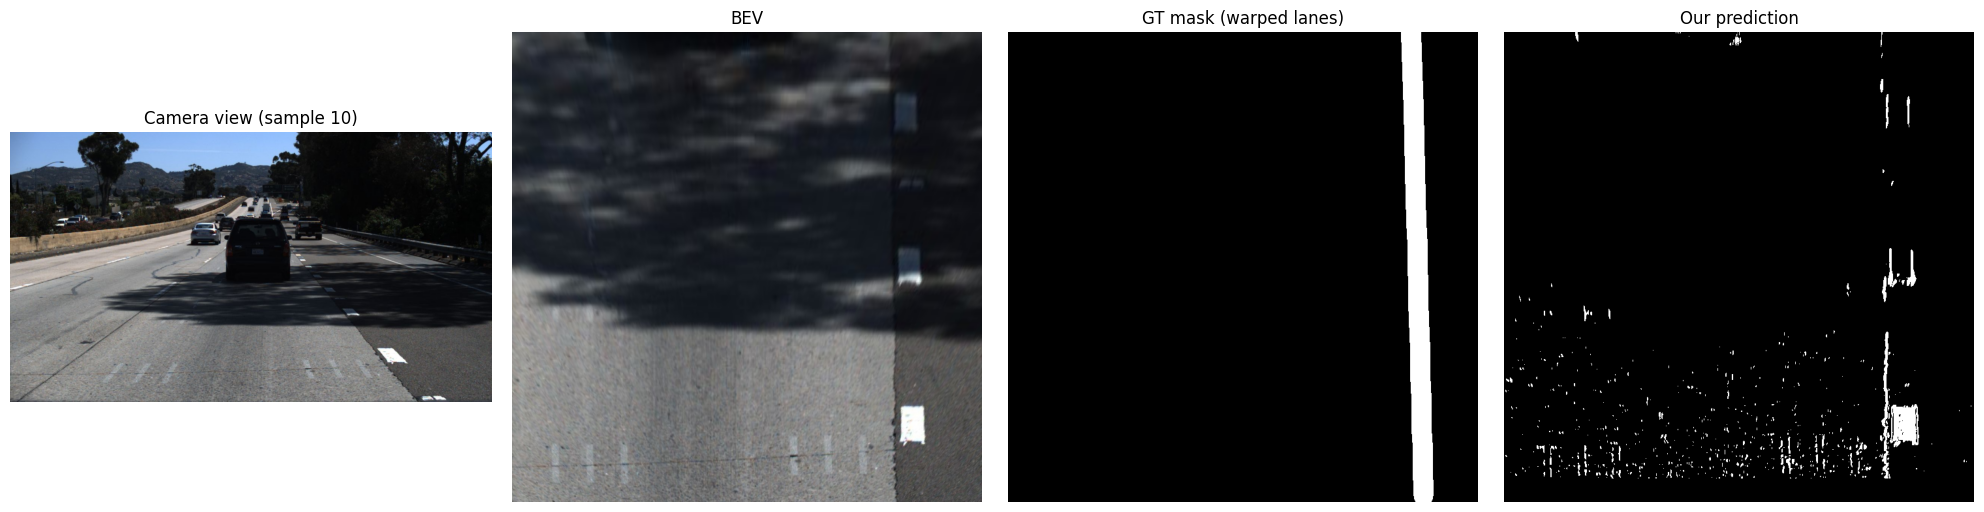

GT lane pixels in BEV: 22301
Predicted lane pixels: 8785
Visible lanes in original: 4
Saved failure case figure for the report.


In [15]:
# Investigate sample 10 — why is its recall so low?
diag_idx = 10
s = dataset[diag_idx]
img = cv2.cvtColor(cv2.imread(str(s.image_path)), cv2.COLOR_BGR2RGB)
bev_i = warper.warp_image(img)
pred = threshold_pipeline(bev_i)
gt = make_gt_mask(s, warper, bev_i.shape[:2], line_thickness=30)

# Visualize: original camera view, BEV, GT mask, predicted mask, overlap
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img); axes[0].set_title(f"Camera view (sample {diag_idx})")
axes[1].imshow(bev_i); axes[1].set_title("BEV")
axes[2].imshow(gt, cmap="gray"); axes[2].set_title("GT mask (warped lanes)")
axes[3].imshow(pred, cmap="gray"); axes[3].set_title("Our prediction")
for ax in axes.flat: ax.axis("off")
plt.tight_layout(); plt.show()

print(f"GT lane pixels in BEV: {np.sum(gt == 255)}")
print(f"Predicted lane pixels: {np.sum(pred == 255)}")
print(f"Visible lanes in original: {s.num_visible_lanes}")

fig.savefig(project_root / "results" / "failure_case_sample10.png", dpi=120, bbox_inches="tight")
print("Saved failure case figure for the report.")